In [13]:
import pandas as pd

df = pd.read_csv(r"C:\Users\leoen\Downloads\Practica 1\dataset_limpio.csv")

tabla_recetas = (
    df.groupby(
        ["recipe_number", "recipe_code", "recipe_name"],
        as_index=False
    )
    .agg(
        numero_resenas=("comment_id", "count"),
        promedio_estrellas=("stars", "mean"),
        mediana_estrellas=("stars", "median"),
        total_me_gusta=("thumbs_up", "sum"),
        total_no_me_gusta=("thumbs_down", "sum"),
        promedio_best_score=("best_score", "mean"),
        total_respuestas=("reply_count", "sum")
    )
    .sort_values("recipe_number")
)

tabla_recetas.to_csv("tabla_resumen_recetas.csv", index=False)

print(tabla_recetas.shape)
display(tabla_recetas.style.hide(axis="index"))

(100, 10)


recipe_number,recipe_code,recipe_name,numero_resenas,promedio_estrellas,mediana_estrellas,total_me_gusta,total_no_me_gusta,promedio_best_score,total_respuestas
1,14299,Creamy White Chili,654,4.452599,5.000000,332,145,130.729358,10
2,3309,Best Ever Banana Bread,509,4.587426,5.000000,163,66,126.222004,5
3,2832,Cheeseburger Soup,725,4.576552,5.000000,734,488,136.362759,16
4,17826,Amish Breakfast Casserole,338,4.526627,5.000000,971,328,191.952663,3
5,42386,Pumpkin Spice Cupcakes with Cream Cheese Frosting,197,4.461929,5.000000,26,13,111.751269,0
6,21444,Favorite Chicken Potpie,395,4.513924,5.000000,364,149,153.810127,6
7,12540,Flavorful Chicken Fajitas,368,4.608696,5.000000,289,168,160.855978,4
8,6086,Apple Pie,241,4.082988,5.000000,310,262,157.103734,2
9,42083,Enchilada Casser-Ole!,421,4.099762,5.000000,207,80,123.456057,2
10,2912,Zucchini Pizza Casserole,332,4.632530,5.000000,212,120,162.746988,2


## 0. Unidad de análisis y tabla agregada

El archivo original tiene una fila por comentario. Por eso, inicialmente cada observación representa una reseña individual.

Para este análisis, la unidad de análisis cambia de **comentario** a **receta**. Los comentarios se agrupan utilizando `recipe_number`, `recipe_code` y `recipe_name`. Como resultado, `tabla_recetas` tiene **100 filas**, una por receta.

Cada fila de `tabla_recetas` resume la actividad de una receta mediante estas medidas:

- `numero_resenas`: cantidad de comentarios recibidos.
- `promedio_estrellas` y `mediana_estrellas`: resumen de las calificaciones.
- `total_me_gusta` y `total_no_me_gusta`: interacción acumulada.
- `promedio_best_score`: puntuación media de sus comentarios.
- `total_respuestas`: suma de respuestas recibidas.

Esta tabla agregada es la base para comparar recetas, calcular estadísticas, construir rankings y estudiar la relación entre valoración e interacción.

## 1. Modelo entidad-relación

El dataset contiene tres entidades principales:

- **Receta**: identificada por `recipe_number`, `recipe_code` y `recipe_name`.
- **Usuario**: identificado por `user_id`, `user_name` y `user_reputation`.
- **Comentario o reseña**: identificado por `comment_id`. Incluye la fecha (`created_at`), el texto (`text`), la calificación (`stars`), `best_score`, el número de respuestas (`reply_count`), los votos positivos y negativos (`thumbs_up` y `thumbs_down`) y el estado de la calificación (`rating_status`).

Un usuario puede escribir comentarios sobre muchas recetas y una receta puede recibir comentarios de muchos usuarios. Por tanto, la relación entre **Usuario** y **Receta** es de muchos a muchos.

La entidad **Comentario/Reseña** resuelve esta relación porque cada comentario conecta exactamente a un usuario con una receta en una fecha determinada. Las cardinalidades son:

- Una **Receta** puede tener muchos comentarios: **Receta 1:N Comentario**.
- Un **Usuario** puede escribir muchos comentarios: **Usuario 1:N Comentario**.
- Cada comentario pertenece a una sola receta y a un solo usuario.

En términos de base de datos, `Comentario/Reseña` funciona como la tabla intermedia entre `Usuario` y `Receta`.

In [8]:
metricas = {
    "numero_resenas": "Número de reseñas por receta",
    "promedio_estrellas": "Promedio de estrellas",
    "total_me_gusta": "Thumbs up totales",
    "total_no_me_gusta": "Thumbs down totales",
    "promedio_best_score": "Promedio de best_score"
}

columnas_metricas = list(metricas.keys())
tabla_estadistica = (
    tabla_recetas[columnas_metricas]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    .rename(columns={
        "count": "n",
        "mean": "media",
        "std": "desviacion_estandar",
        "min": "minimo",
        "25%": "q1",
        "50%": "mediana",
        "75%": "q3",
        "max": "maximo"
    })
)

tabla_estadistica["rango"] = (
    tabla_estadistica["maximo"] - tabla_estadistica["minimo"]
)
tabla_estadistica.index = [metricas[columna] for columna in columnas_metricas]
tabla_estadistica = tabla_estadistica[
    [
        "n",
        "media",
        "mediana",
        "desviacion_estandar",
        "minimo",
        "q1",
        "q3",
        "maximo",
        "rango"
    ]
].reset_index(names="metrica")

tabla_moda = pd.DataFrame({
    "metrica": [metricas[columna] for columna in columnas_metricas],
    "moda": [
        tabla_recetas[columna].mode().iloc[0]
        for columna in columnas_metricas
    ]
})

formato_estadistica = {
    columna: ("{:.0f}" if columna == "n" else "{:.2f}")
    for columna in tabla_estadistica.columns
    if columna != "metrica"
}

print("Resumen estadístico por métrica")
display(
    tabla_estadistica.style
    .hide(axis="index")
    .format(formato_estadistica)
    .background_gradient(cmap="YlGnBu", subset=["media", "mediana"])
)

print("Moda por métrica")
display(
    tabla_moda.style.format("{:.2f}", subset=["moda"]).hide(axis="index")
)

Resumen estadístico por métrica


metrica,n,media,mediana,desviacion_estandar,minimo,q1,q3,maximo,rango
Número de reseñas por receta,100,181.82,149.00,106.80,31.00,128.00,191.75,725.00,694.00
Promedio de estrellas,100,4.25,4.32,0.32,2.61,4.10,4.46,4.73,2.12
Thumbs up totales,100,198.05,157.50,177.93,5.00,56.75,297.75,971.00,966.00
Thumbs down totales,100,99.88,75.50,94.22,2.00,29.50,143.50,488.00,486.00
Promedio de best_score,100,156.19,148.43,33.64,105.51,131.08,178.32,253.02,147.50


Moda por métrica


metrica,moda
Número de reseñas por receta,128.00
Promedio de estrellas,4.21
Thumbs up totales,19.00
Thumbs down totales,19.00
Promedio de best_score,105.51


## 2. Estadística descriptiva por receta

Esta sección resume las **100 recetas** de `tabla_recetas`. Cada fila de la tabla estadística representa una métrica calculada sobre las recetas, no sobre los comentarios individuales.

Las métricas analizadas son:

- **Número de reseñas**: cantidad de comentarios asociados a cada receta.
- **Promedio de estrellas**: valoración media de cada receta.
- **Thumbs up totales**: suma de votos positivos recibidos por cada receta.
- **Thumbs down totales**: suma de votos negativos recibidos por cada receta.
- **Promedio de `best_score`**: puntuación media de interacción o relevancia de los comentarios de cada receta.

En la tabla, `media` indica el promedio entre las 100 recetas y `mediana` representa el valor central: la mitad de las recetas queda por debajo y la otra mitad por encima. `desviacion_estandar` mide cuánto se separan los valores de la media. `q1` y `q3` son el primer y tercer cuartil; entre ambos se encuentra el 50% central de las recetas. `rango` es la diferencia entre el máximo y el mínimo.

La receta típica tiene **181.82 reseñas**, una mediana de **149 reseñas** y un promedio de **4.25 estrellas**. La diferencia entre media y mediana en el número de reseñas indica que algunas recetas tienen un volumen de comentarios especialmente alto.

Los `thumbs up` presentan una desviación estándar de **177.93** y un rango de **966**, lo que muestra grandes diferencias de popularidad entre recetas. En cambio, el promedio de estrellas se concentra más: su desviación estándar es **0.32**.

In [9]:
# Correlaciones a nivel comentario individual
variables_comentario = [
    "stars",
    "thumbs_up",
    "thumbs_down",
    "reply_count",
    "best_score"
]

correlacion_comentarios_pearson = df[variables_comentario].corr(method="pearson")
correlacion_comentarios_spearman = df[variables_comentario].corr(method="spearman")

# Correlaciones a nivel receta agregada
variables_receta = [
    "promedio_estrellas",
    "total_me_gusta",
    "total_no_me_gusta",
    "total_respuestas",
    "promedio_best_score"
]

correlacion_recetas_pearson = tabla_recetas[variables_receta].corr(method="pearson")
correlacion_recetas_spearman = tabla_recetas[variables_receta].corr(method="spearman")

def mostrar_correlacion(matriz):
    tabla = matriz.round(3).rename_axis("variable").reset_index()
    display(tabla.style.hide(axis="index"))

print("Correlación de Pearson: comentarios")
mostrar_correlacion(correlacion_comentarios_pearson)

print("Correlación de Pearson: recetas agregadas")
mostrar_correlacion(correlacion_recetas_pearson)

print("Correlación de Spearman: comentarios")
mostrar_correlacion(correlacion_comentarios_spearman)

print("Correlación de Spearman: recetas agregadas")
mostrar_correlacion(correlacion_recetas_spearman)

Correlación de Pearson: comentarios


variable,stars,thumbs_up,thumbs_down,reply_count,best_score
stars,1.000000,-0.051000,-0.143000,-0.120000,-0.034000
thumbs_up,-0.051000,1.000000,0.373000,0.209000,0.685000
thumbs_down,-0.143000,0.373000,1.000000,0.328000,0.215000
reply_count,-0.120000,0.209000,0.328000,1.000000,0.201000
best_score,-0.034000,0.685000,0.215000,0.201000,1.000000


Correlación de Pearson: recetas agregadas


variable,promedio_estrellas,total_me_gusta,total_no_me_gusta,total_respuestas,promedio_best_score
promedio_estrellas,1.000000,0.119000,0.085000,0.061000,0.106000
total_me_gusta,0.119000,1.000000,0.890000,0.596000,0.666000
total_no_me_gusta,0.085000,0.890000,1.000000,0.617000,0.600000
total_respuestas,0.061000,0.596000,0.617000,1.000000,0.344000
promedio_best_score,0.106000,0.666000,0.600000,0.344000,1.000000


Correlación de Spearman: comentarios


variable,stars,thumbs_up,thumbs_down,reply_count,best_score
stars,1.000000,-0.039000,-0.157000,-0.121000,-0.032000
thumbs_up,-0.039000,1.000000,0.495000,0.177000,0.972000
thumbs_down,-0.157000,0.495000,1.000000,0.219000,0.448000
reply_count,-0.121000,0.177000,0.219000,1.000000,0.179000
best_score,-0.032000,0.972000,0.448000,0.179000,1.000000


Correlación de Spearman: recetas agregadas


variable,promedio_estrellas,total_me_gusta,total_no_me_gusta,total_respuestas,promedio_best_score
promedio_estrellas,1.000000,0.142000,0.090000,0.029000,0.069000
total_me_gusta,0.142000,1.000000,0.914000,0.621000,0.798000
total_no_me_gusta,0.090000,0.914000,1.000000,0.590000,0.744000
total_respuestas,0.029000,0.621000,0.590000,1.000000,0.439000
promedio_best_score,0.069000,0.798000,0.744000,0.439000,1.000000


## 3. Valoración e interacción: correlaciones

En esta sección se estudia si una mejor valoración está relacionada con una mayor interacción.

Se comparan las estrellas con cuatro variables de interacción:

- `thumbs_up`: votos positivos.
- `thumbs_down`: votos negativos.
- `reply_count`: respuestas recibidas.
- `best_score`: puntuación asociada al comentario.

El análisis se realiza en dos niveles:

1. **Nivel comentario**: cada fila representa una reseña individual y se utiliza `stars`.
2. **Nivel receta**: los comentarios se agrupan por receta y se utiliza `promedio_estrellas`, junto con los totales o promedios de interacción.

El coeficiente de correlación varía entre -1 y 1. Valores cercanos a 0 indican una relación lineal débil; valores cercanos a 1 indican una relación positiva fuerte. Pearson mide principalmente relaciones lineales y Spearman mide relaciones monotónicas, incluso cuando no son perfectamente lineales.

A nivel comentario, `stars` tiene correlaciones débiles con `thumbs_up` (**-0.051**), `thumbs_down` (**-0.143**) y `reply_count` (**-0.120**). Esto significa que una reseña con muchas estrellas no necesariamente recibe más interacción.

En cambio, `best_score` y `thumbs_up` presentan una relación positiva clara: Pearson es **0.685** y Spearman es **0.972** a nivel comentario. A nivel receta, la correlación entre `promedio_best_score` y `total_me_gusta` es **0.666** según Pearson y **0.798** según Spearman.

La conclusión es que las estrellas representan valoración, mientras que `best_score` está más relacionado con la popularidad o visibilidad del comentario.

In [10]:
ranking_reseñas = (
    tabla_recetas[
        ["recipe_number", "recipe_name", "numero_resenas", "promedio_estrellas"]
    ]
    .sort_values(
        ["numero_resenas", "recipe_name"],
        ascending=[False, True]
    )
    .assign(posicion_popularidad=lambda tabla: tabla["numero_resenas"].rank(
        method="min", ascending=False
    ).astype(int))
)

ranking_valoracion = (
    tabla_recetas[
        ["recipe_number", "recipe_name", "promedio_estrellas", "numero_resenas"]
    ]
    .sort_values(
        ["promedio_estrellas", "recipe_name"],
        ascending=[False, True]
    )
    .assign(posicion_valoracion=lambda tabla: tabla["promedio_estrellas"].rank(
        method="min", ascending=False
    ).astype(int))
)

comparacion_rankings = (
    tabla_recetas[
        ["recipe_number", "recipe_name", "numero_resenas", "promedio_estrellas"]
    ]
    .assign(
        posicion_popularidad=lambda tabla: tabla["numero_resenas"].rank(
            method="min", ascending=False
        ).astype(int),
        posicion_valoracion=lambda tabla: tabla["promedio_estrellas"].rank(
            method="min", ascending=False
        ).astype(int)
    )
    .assign(
        diferencia_posiciones=lambda tabla: (
            tabla["posicion_popularidad"] - tabla["posicion_valoracion"]
        ).abs()
    )
    .sort_values("posicion_popularidad")
)

correlacion_posiciones = comparacion_rankings[
    ["posicion_popularidad", "posicion_valoracion"]
].corr(method="spearman").iloc[0, 1]

print("Top 10 por número de reseñas")
display(ranking_reseñas.head(10).style.hide(axis="index"))

print("Top 10 por promedio de estrellas")
display(ranking_valoracion.head(10).style.hide(axis="index"))

print(f"Correlación de Spearman entre ambos rankings: {correlacion_posiciones:.3f}")
display(comparacion_rankings.head(10).style.hide(axis="index"))

Top 10 por número de reseñas


recipe_number,recipe_name,numero_resenas,promedio_estrellas,posicion_popularidad
3,Cheeseburger Soup,725,4.576552,1
1,Creamy White Chili,654,4.452599,2
2,Best Ever Banana Bread,509,4.587426,3
9,Enchilada Casser-Ole!,421,4.099762,4
13,Basic Homemade Bread,397,3.894207,5
6,Favorite Chicken Potpie,395,4.513924,6
7,Flavorful Chicken Fajitas,368,4.608696,7
4,Amish Breakfast Casserole,338,4.526627,8
10,Zucchini Pizza Casserole,332,4.632530,9
12,Cauliflower Soup,324,4.530864,10


Top 10 por promedio de estrellas


recipe_number,recipe_name,promedio_estrellas,numero_resenas,posicion_valoracion
16,Rustic Italian Tortellini Soup,4.731343,268,1
44,Corn Pudding,4.711409,149,2
36,Pumpkin Bread,4.645349,172,3
27,Macaroni Coleslaw,4.633508,191,4
10,Zucchini Pizza Casserole,4.632530,332,5
55,Special Banana Nut Bread,4.609023,133,6
7,Flavorful Chicken Fajitas,4.608696,368,7
11,Traditional Lasagna,4.605072,276,8
83,Comforting Chicken Noodle Soup,4.600000,105,9
2,Best Ever Banana Bread,4.587426,509,10


Correlación de Spearman entre ambos rankings: 0.281


recipe_number,recipe_name,numero_resenas,promedio_estrellas,posicion_popularidad,posicion_valoracion,diferencia_posiciones
3,Cheeseburger Soup,725,4.576552,1,11,10
1,Creamy White Chili,654,4.452599,2,28,26
2,Best Ever Banana Bread,509,4.587426,3,10,7
9,Enchilada Casser-Ole!,421,4.099762,4,75,71
13,Basic Homemade Bread,397,3.894207,5,92,87
6,Favorite Chicken Potpie,395,4.513924,6,19,13
7,Flavorful Chicken Fajitas,368,4.608696,7,7,0
4,Amish Breakfast Casserole,338,4.526627,8,16,8
10,Zucchini Pizza Casserole,332,4.632530,9,5,4
12,Cauliflower Soup,324,4.530864,10,14,4


## 4. Rankings de popularidad y valoración

Aquí se construyen dos rankings independientes para las mismas 100 recetas:

- **Ranking de popularidad**: ordena las recetas de mayor a menor `numero_resenas`, es decir, según la cantidad total de comentarios recibidos.
- **Ranking de valoración**: ordena las recetas de mayor a menor `promedio_estrellas`, es decir, según la calificación media de sus comentarios.

La columna `posicion_popularidad` indica el lugar de una receta en el primer ranking. La columna `posicion_valoracion` indica su lugar en el segundo. `diferencia_posiciones` muestra cuántos lugares separan ambos resultados.

Los rankings no miden lo mismo. `Cheeseburger Soup` es la receta con más reseñas, pero ocupa la posición **11** en valoración. En cambio, `Rustic Italian Tortellini Soup` ocupa la posición **1** en valoración y la **16** en número de reseñas.

La correlación de Spearman entre ambas posiciones es **0.281**, una relación baja. Por tanto, una receta muy comentada no necesariamente es la mejor valorada, y una receta muy bien valorada puede tener menos comentarios.

Recetas con mayor desviación estándar de estrellas válidas


recipe_number,recipe_name,desviacion_stars,numero_resenas_validas
86,First-Place Coconut Macaroons,1.129000,128
8,Apple Pie,1.108000,218
51,Fluffy Pancakes,1.074000,138
77,Cherry Bars,1.059000,123
57,Favorite Dutch Apple Pie,1.028000,135
97,Lime Chicken Tacos,1.026000,76
26,Hot Milk Cake,1.024000,210
94,Easy Peanut Butter Fudge,0.995000,91
62,Pork Chops with Scalloped Potatoes,0.993000,142
54,Cheeseburger Paradise Soup,0.986000,90


Recetas con mayor proporción de thumbs down


recipe_number,recipe_name,proporcion_thumbs_down,total_thumbs_up,total_thumbs_down
66,Chocolate Caramel Candy,0.750000,5,15
42,Garlic Beef Enchiladas,0.592000,58,84
30,Forgotten Jambalaya,0.562000,35,45
60,Slow-Cooker Lasagna,0.528000,17,19
95,Bacon Macaroni Salad,0.521000,78,85
37,Taco Lasagna,0.487000,193,183
78,Creamy Macaroni and Cheese,0.482000,86,80
38,Frosted Banana Bars,0.468000,101,89
44,Corn Pudding,0.464000,104,90
20,Mom’s Meat Loaf,0.462000,307,264


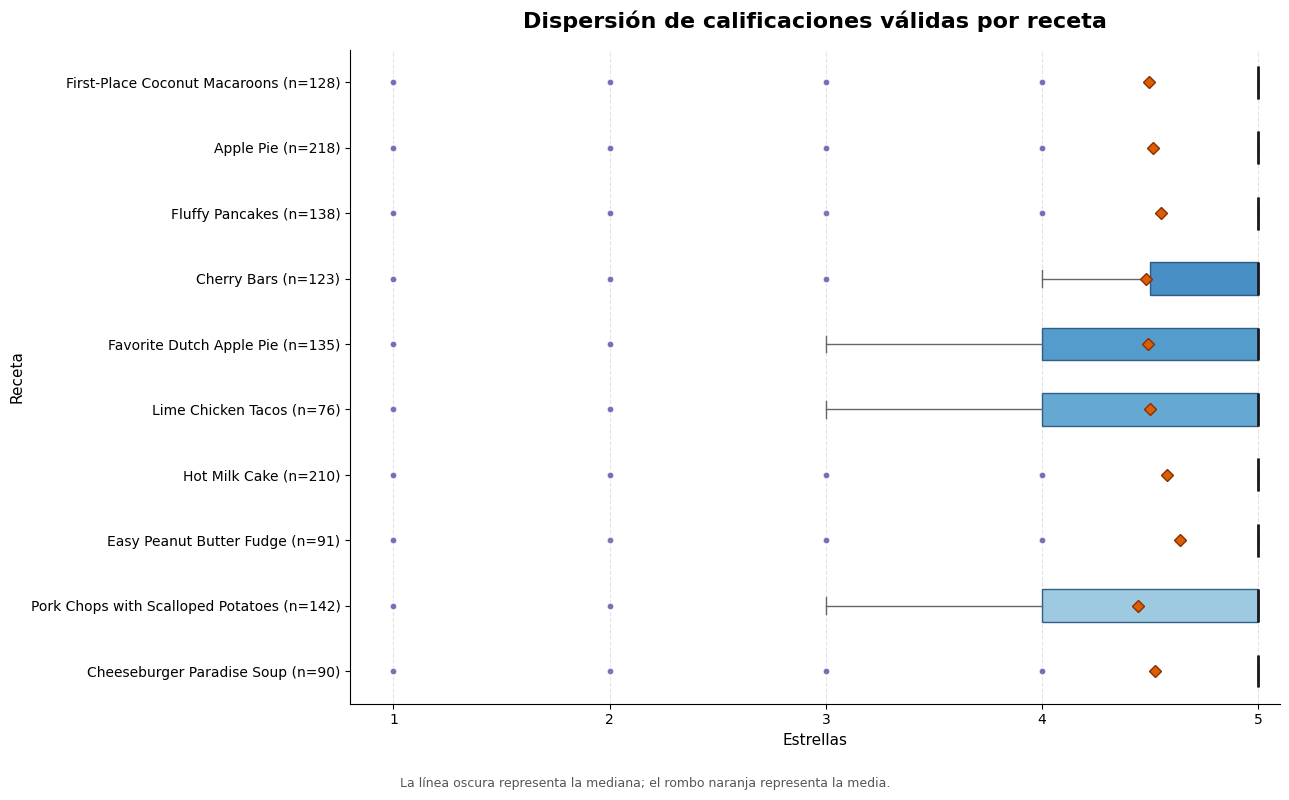

In [11]:
import matplotlib.pyplot as plt

comentarios_validos = df[df["rating_valid"]].copy()

resumen_estrellas = (
    comentarios_validos.groupby(["recipe_number", "recipe_name"], as_index=False)
    .agg(
        desviacion_stars=("stars", "std"),
        promedio_stars_dispersion=("stars", "mean"),
        numero_resenas_validas=("comment_id", "count")
    )
)

resumen_interacciones = (
    df.groupby(["recipe_number", "recipe_name"], as_index=False)
    .agg(
        total_thumbs_up=("thumbs_up", "sum"),
        total_thumbs_down=("thumbs_down", "sum"),
        numero_comentarios=("comment_id", "count")
    )
)

resumen_dispersion = (
    resumen_estrellas.merge(
        resumen_interacciones,
        on=["recipe_number", "recipe_name"]
    )
    .assign(
        proporcion_thumbs_down=lambda tabla: tabla["total_thumbs_down"] / (
            tabla["total_thumbs_up"] + tabla["total_thumbs_down"]
        ).replace(0, pd.NA)
    )
    .fillna({"desviacion_stars": 0, "proporcion_thumbs_down": 0})
    .sort_values("desviacion_stars", ascending=False)
)

print("Recetas con mayor desviación estándar de estrellas válidas")
display(
    resumen_dispersion[
        [
            "recipe_number",
            "recipe_name",
            "desviacion_stars",
            "numero_resenas_validas"
        ]
    ].head(10).round(3).style.hide(axis="index")
)

print("Recetas con mayor proporción de thumbs down")
display(
    resumen_dispersion.sort_values(
        "proporcion_thumbs_down", ascending=False
    )[
        [
            "recipe_number",
            "recipe_name",
            "proporcion_thumbs_down",
            "total_thumbs_up",
            "total_thumbs_down"
        ]
    ].head(10).round(3).style.hide(axis="index")
)

top_recetas_dispersion = resumen_dispersion.head(10).copy()
top_recetas_dispersion = top_recetas_dispersion.sort_values(
    "desviacion_stars", ascending=True
)

datos_boxplot = [
    comentarios_validos.loc[
        comentarios_validos["recipe_name"] == nombre,
        "stars"
    ].dropna().tolist()
    for nombre in top_recetas_dispersion["recipe_name"]
]
etiquetas_boxplot = [
    f"{nombre} (n={n})"
    for nombre, n in zip(
        top_recetas_dispersion["recipe_name"],
        top_recetas_dispersion["numero_resenas_validas"]
    )
]

fig, ax = plt.subplots(figsize=(13, 8))
boxplot = ax.boxplot(
    datos_boxplot,
    vert=False,
    patch_artist=True,
    tick_labels=etiquetas_boxplot,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "#d95f02",
        "markeredgecolor": "#8c2d04",
        "markersize": 6
    },
    medianprops={"color": "#1b1b1b", "linewidth": 2},
    whiskerprops={"color": "#666666"},
    capprops={"color": "#666666"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#7570b3",
        "markeredgecolor": "white",
        "markersize": 5,
        "alpha": 0.8
    }
)

colores = plt.cm.Blues(
    [0.35 + (0.55 * posicion / len(boxplot["boxes"]))
     for posicion in range(len(boxplot["boxes"]))]
)
for caja, color in zip(boxplot["boxes"], colores):
    caja.set_facecolor(color)
    caja.set_edgecolor("#24527a")
    caja.set_alpha(0.9)

ax.set_title(
    "Dispersión de calificaciones válidas por receta",
    fontsize=16,
    fontweight="bold",
    pad=16
)
ax.set_xlabel("Estrellas", fontsize=11)
ax.set_ylabel("Receta", fontsize=11)
ax.set_xlim(0.8, 5.1)
ax.set_xticks(range(1, 6))
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.text(
    0.5,
    0.01,
    "La línea oscura representa la mediana; el rombo naranja representa la media.",
    ha="center",
    fontsize=9,
    color="#555555"
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 5. Dispersión y controversia por receta

Esta sección mide si las opiniones sobre una receta son homogéneas o están divididas.

Para calcular la dispersión de las estrellas se utilizan únicamente los comentarios con `rating_valid == True`. Esto es importante porque los comentarios sin calificación tienen `stars = 0`, pero ese cero no representa una opinión de una estrella.

La medida principal es `desviacion_stars`:

- Una desviación estándar alta significa que las calificaciones están muy separadas y que existen opiniones más divididas.
- Una desviación estándar baja significa que las calificaciones se concentran alrededor de un valor y que existe mayor consenso.

Como medida complementaria se calcula `proporcion_thumbs_down`, definida como:

$$
\text{proporción de thumbs down} =
\frac{\text{thumbs down}}{\text{thumbs up} + \text{thumbs down}}
$$

Esta proporción debe interpretarse junto con el número total de votos. Por ejemplo, `Chocolate Caramel Candy` tiene una proporción de `thumbs_down` de **0.750**, pero se basa en solo 20 votos.

Según la desviación estándar de estrellas válidas, las recetas con opiniones más divididas son `First-Place Coconut Macaroons` (**1.129**), `Apple Pie` (**1.108**) y `Fluffy Pancakes` (**1.074**).

En el boxplot, cada fila representa una receta. La caja muestra el 50% central de las calificaciones, la línea oscura es la mediana, el rombo naranja es la media y los puntos aislados son valores atípicos. Las etiquetas indican el número de reseñas válidas utilizadas.

In [12]:
proporciones_receta = (
    df.groupby(["recipe_number", "recipe_name"], as_index=False)
    .agg(
        total_comentarios=("comment_id", "count"),
        comentarios_rating_valid=("rating_valid", "sum"),
        comentarios_con_texto=("has_comment_text", "sum")
    )
    .assign(
        porcentaje_rating_valid=lambda tabla: (
            tabla["comentarios_rating_valid"]
            / tabla["total_comentarios"] * 100
        ),
        porcentaje_con_texto=lambda tabla: (
            tabla["comentarios_con_texto"]
            / tabla["total_comentarios"] * 100
        )
    )
)

comentarios_categorizados = df.assign(
    categoria_interaccion=lambda tabla: tabla.apply(
        lambda fila: (
            "Calificación y texto"
            if fila["rating_valid"] and fila["has_comment_text"]
            else "Solo calificación"
            if fila["rating_valid"]
            else "Solo texto"
            if fila["has_comment_text"]
            else "Sin calificación ni texto"
        ),
        axis=1
    )
)

resumen_categorias = (
    comentarios_categorizados.groupby(
        ["recipe_number", "recipe_name", "categoria_interaccion"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "comentarios"})
)

resumen_categorias["porcentaje"] = (
    resumen_categorias["comentarios"]
    / resumen_categorias.groupby("recipe_number")["comentarios"].transform("sum")
    * 100
)

print("Proporciones de calificación y texto por receta")
display(
    proporciones_receta[
        [
            "recipe_number",
            "recipe_name",
            "total_comentarios",
            "comentarios_rating_valid",
            "porcentaje_rating_valid",
            "comentarios_con_texto",
            "porcentaje_con_texto"
        ]
    ].round(2).head(10).style.hide(axis="index")
)

print("Distribución general de categorías")
display(
    resumen_categorias.groupby("categoria_interaccion", as_index=False)
    .agg(comentarios=("comentarios", "sum"))
    .assign(
        porcentaje=lambda tabla: (
            tabla["comentarios"] / tabla["comentarios"].sum() * 100
        )
    )
    .sort_values("porcentaje", ascending=False)
    .round(2)
    .style.hide(axis="index")
)

Proporciones de calificación y texto por receta


recipe_number,recipe_name,total_comentarios,comentarios_rating_valid,porcentaje_rating_valid,comentarios_con_texto,porcentaje_con_texto
1,Creamy White Chili,654,601,91.900000,654,100.000000
2,Best Ever Banana Bread,509,485,95.280000,509,100.000000
3,Cheeseburger Soup,725,700,96.550000,724,99.860000
4,Amish Breakfast Casserole,338,323,95.560000,338,100.000000
5,Pumpkin Spice Cupcakes with Cream Cheese Frosting,197,181,91.880000,197,100.000000
6,Favorite Chicken Potpie,395,369,93.420000,394,99.750000
7,Flavorful Chicken Fajitas,368,345,93.750000,368,100.000000
8,Apple Pie,241,218,90.460000,241,100.000000
9,Enchilada Casser-Ole!,421,367,87.170000,421,100.000000
10,Zucchini Pizza Casserole,332,324,97.590000,332,100.000000


Distribución general de categorías


categoria_interaccion,comentarios,porcentaje
Calificación y texto,16482,90.650000
Solo texto,1695,9.320000
Solo calificación,4,0.020000
Sin calificación ni texto,1,0.010000


## 6. Proporciones de calificación y texto

Esta sección describe qué tipo de información aporta cada comentario para cada receta.

Se calculan dos porcentajes sobre el total de comentarios de cada receta:

- `porcentaje_rating_valid`: porcentaje de comentarios con una calificación numérica válida (`rating_valid == True`).
- `porcentaje_con_texto`: porcentaje de comentarios que contienen texto (`has_comment_text == True`).

Además, cada comentario se clasifica en una de cuatro categorías:

- **Calificación y texto**: tiene estrellas válidas y contenido escrito.
- **Solo texto**: contiene una opinión escrita, pero no una calificación numérica válida.
- **Solo calificación**: tiene estrellas válidas, pero no texto.
- **Sin calificación ni texto**: no aporta ninguno de los dos elementos.

En el conjunto completo, el **90.65%** de los comentarios tiene calificación y texto. El **9.32%** contiene solo texto. Los casos de solo calificación (**0.02%**) y sin calificación ni texto (**0.01%**) son prácticamente inexistentes.

Esto significa que la mayoría de los comentarios puede utilizarse tanto para analizar valoración numérica como para analizar opiniones escritas. Sin embargo, el **9.32%** solo puede estudiarse mediante texto, porque no tiene una estrella válida.

La tabla muestra las primeras diez recetas como vista inicial; el objeto `proporciones_receta` contiene el resultado completo para las 100 recetas.

# Conclusiones finales

## Conclusión 1: unidad de análisis y agregación

En la sección **0. Unidad de análisis y tabla agregada**, la tabla `tabla_recetas` transforma los comentarios individuales en una tabla de **100 recetas**. Esta tabla concentra el número de reseñas, las estrellas, los votos positivos y negativos, `best_score` y las respuestas. Por ello, los análisis posteriores comparan recetas y no comentarios individuales, salvo cuando se indica expresamente lo contrario.

## Conclusión 2: estructura de los datos

En la sección **1. Modelo entidad-relación**, el texto identifica las entidades **Receta**, **Usuario** y **Comentario/Reseña**. La tabla `Comentario/Reseña` funciona como intermediaria entre usuarios y recetas: cada comentario relaciona un usuario con una receta. Esto justifica las cardinalidades **Receta 1:N Comentario** y **Usuario 1:N Comentario**.

## Conclusión 3: comportamiento estadístico de las recetas

En la sección **2. Estadística descriptiva por receta**, la tabla `tabla_estadistica` muestra que una receta tiene, en promedio, **181.82 reseñas** y **4.25 estrellas**. La desviación estándar de `total_me_gusta` es **177.93**, mucho mayor que la desviación estándar del promedio de estrellas (**0.32**). Por tanto, las recetas son relativamente parecidas en valoración, pero muy diferentes en popularidad e interacción.

## Conclusión 4: valoración e interacción no son equivalentes

En la sección **3. Valoración e interacción: correlaciones**, las tablas de correlación muestran que `stars` tiene una relación débil con `thumbs_up`, `thumbs_down` y `reply_count`. A nivel comentario, la correlación Pearson entre `stars` y `thumbs_up` es **-0.051**. En cambio, `best_score` y `thumbs_up` presentan una relación positiva de **0.685** según Pearson y **0.972** según Spearman.

La conclusión es que tener más estrellas no implica recibir más interacción. En cambio, `best_score` está mucho más relacionado con la popularidad del comentario.

## Conclusión 5: popularidad y valoración producen rankings diferentes

En la sección **4. Rankings de popularidad y valoración**, las tablas `ranking_reseñas`, `ranking_valoracion` y `comparacion_rankings` muestran que los dos criterios no son equivalentes. `Cheeseburger Soup` ocupa la posición **1** por número de reseñas, pero la posición **11** por promedio de estrellas. `Rustic Italian Tortellini Soup` ocupa la posición **1** por valoración, pero la posición **16** por número de reseñas.

La correlación de Spearman entre las posiciones es **0.281**, lo que confirma una relación baja entre popularidad y valoración.

## Conclusión 6: recetas con opiniones más divididas

En la sección **5. Dispersión y controversia por receta**, la tabla `resumen_dispersion` y el boxplot **“Dispersión de calificaciones válidas por receta”** muestran la variabilidad de las estrellas utilizando únicamente comentarios con `rating_valid == True`.

Las mayores desviaciones estándar corresponden a `First-Place Coconut Macaroons` (**1.129**), `Apple Pie` (**1.108**) y `Fluffy Pancakes` (**1.074**). Estas recetas presentan opiniones más heterogéneas. En el boxplot, las cajas amplias indican mayor dispersión y los puntos aislados representan calificaciones atípicas.

## Conclusión 7: calidad de la información disponible

En la sección **6. Proporciones de calificación y texto**, las tablas `proporciones_receta` y `resumen_categorias` muestran qué tipo de información aporta cada comentario. El **90.65%** de los comentarios contiene simultáneamente calificación y texto, mientras que el **9.32%** contiene solo texto.

Esto significa que la mayoría de las reseñas sirve para analizar tanto la valoración numérica como el contenido escrito. Sin embargo, el 9.32% solo puede utilizarse para análisis textual, porque no contiene una estrella válida.

## Conclusión general

En conjunto, los resultados muestran que la valoración y la interacción representan dimensiones diferentes. Las estrellas reflejan la opinión media de los usuarios, mientras que el número de reseñas, los votos y `best_score` reflejan visibilidad, participación y popularidad. Por eso, una receta puede ser muy comentada sin ser la mejor valorada, o puede tener una valoración alta sin concentrar el mayor volumen de interacción.